Crab Flux Calculations

In [97]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scienceplots
plt.style.use(['science','ieee'])
cmap = plt.get_cmap('cool')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

### Parse TransientX Pulses 

In [98]:
snr, width = np.loadtxt('./CrabGPs/CrabGP_SNR_Width.dat', unpack=True)
print('Number of detected pulses', len(snr))

Number of detected pulses 1041353


### Parse Fitted `.ar` pulses 

In [99]:
GPs_pd = pd.read_csv('./CrabGPs/scatteringResults_bestDM_allSubbands.csv')
GPs_grouped = GPs_pd.groupby('MJD')
GPs_avg = GPs_grouped.agg({'Best Tau (ms)': 'mean', 'SNR': 'mean'}).reset_index()
print('Number of unique MJDs', len(GPs_avg))
print('Max SNR', GPs_avg['SNR'].max())
GPs_avg.head()

Number of unique MJDs 5234
Max SNR 7214.018328315085


,MJD,Best Tau (ms),SNR
0,58925.710175,13.12750,324.405973
1,58925.712200,12.70250,202.762088
2,58925.712650,13.18375,706.155686
3,58925.712690,13.69625,304.875153
4,58925.713053,13.99125,1019.904450


## Import measured values for the radiometer equation

In [100]:
# Importing MII values, attained from Vincetti et al. 2026
import re
import ast

mii_results = {}

pattern = re.compile(r"results\[(.*?)\]\s*=\s*(\[.*\])")

with open("./CrabGPs/mii_B0531+21.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        m = pattern.match(line)
        if not m:
            print("Skipping:", line[:80])
            continue

        key = float(m.group(1))
        values = ast.literal_eval(m.group(2))

        mii_results[key] = values
        
print('Keys:', mii_results.keys())

Keys: dict_keys([61024.916666666664, 61024.91736111111, 61024.91805555556, 61024.91875, 61024.919444444444, 61024.92013888889, 61024.92083333333, 61024.92152777778, 61024.92222222222, 61024.92291666667, 61024.92361111111, 61024.924305555556, 61024.925, 61024.92569444444, 61024.92638888889, 61024.927083333336, 61024.927777777775, 61024.92847222222, 61024.92916666667, 61024.92986111111, 61024.930555555555, 61024.93125, 61024.93194444444, 61024.93263888889, 61024.933333333334, 61024.93402777778, 61024.93472222222, 61024.93541666667, 61024.936111111114, 61024.93680555555, 61024.9375, 61024.93819444445, 61024.938888888886, 61024.93958333333, 61024.94027777778, 61024.94097222222, 61024.941666666666, 61024.94236111111, 61024.94305555556, 61024.94375, 61024.944444444445, 61024.94513888889, 61024.94583333333, 61024.94652777778, 61024.947222222225, 61024.947916666664, 61024.94861111111, 61024.94930555556, 61024.95, 61024.950694444444, 61024.95138888889, 61024.95208333333, 61024.95277777778, 6102

Radiometer Equation

$$S_{\min}(f, l, b) = \frac{\left[ T_{\text{sky}}(l,b) + T_{\text{int}}(f) \right] \cdot 2 k_B}{A_{\text{eff}}(f) \cdot m_{II}} \cdot \beta \times \frac{\text{S/N}_{\min}}{\sqrt{n_p\, t_{\text{obs}}\, B_{\text{channel}}}} \cdot \sqrt{\frac{W}{P - W}}$$

In [101]:
def interp_conv_temp(n, freq_mhz, conv_temp_k, fmin=100.0, fmax=190.0):
    f_new = np.linspace(fmin, fmax, int(n))
    t_new = np.interp(f_new, freq_mhz, conv_temp_k)
    return f_new, t_new


def burst_smin(freq, T_sys, A_phys, mii, SNR_limit, W_burst,
               chan_BW, n_p=2, rfi_mask=None):
    """
    Compute the minimum detectable single-burst flux density S_min.

    Parameters
    ----------
    freq : array_like
        Channel center frequencies in MHz.
    T_sys : array_like
        System temperature per channel in K.
    A_phys : float
        Physical collecting area of the telescope in m^2.
    SNR_limit : float
        Required signal-to-noise ratio (dimensionless).
    W_burst : float
        Burst width in seconds.
    chan_BW : float
        Channel bandwidth in MHz.
    mii : array_like
        Mueller matrix (dimensionless)
    n_p : int, optional
        Number of summed polarizations (dimensionless).
    rfi_mask : array_like of bool, optional
        Boolean mask selecting RFI-free channels.

    Returns
    -------
    float
        S_min in mJy.
    """
    k_B = 1380
    chan_BW_Hz = chan_BW * 1e6
    if rfi_mask is not None:
        freq = freq[rfi_mask]
        T_sys = T_sys[rfi_mask]
    S_min_i = (T_sys * 2 * k_B) / (A_phys*mii) * \
              (SNR_limit / np.sqrt(n_p * chan_BW_Hz * W_burst))
    S_min_total = 1.0 / np.sqrt(np.sum(1.0 / S_min_i**2))
    return S_min_total * 1000  # mJy

Text(0.5, 0, 'Frequency')

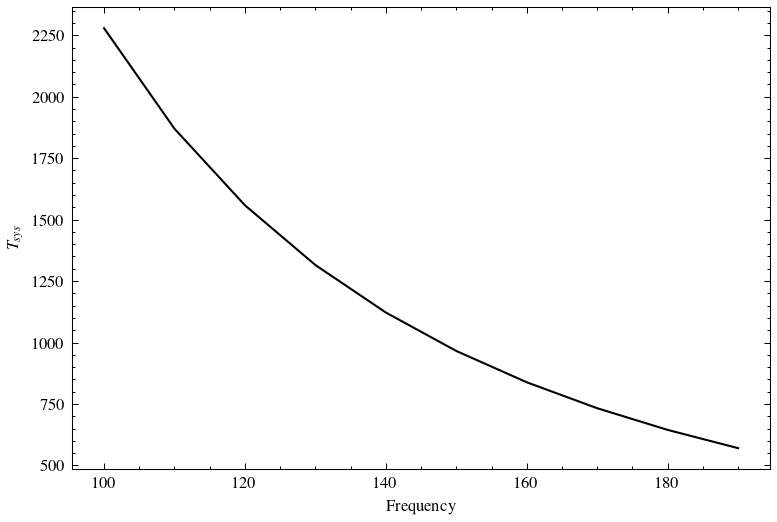

In [102]:
nchans = 3296

conv_temp_k = np.array([2278.8,1869.7,1558.3,1315.2,1122.0,965.53,838.23,732.6,644.45,570.1], dtype=float)
freq_mhz = np.array([100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0, 190.0], dtype=float)
A_phys = np.array([2400, 2048, 1422, 1152])
A_phys_freq = np.array([100.0, 120.0, 150.0, 180.0], dtype=float)

plt.figure(figsize=(6, 4), dpi=150)
plt.plot(freq_mhz, conv_temp_k)
plt.ylabel('$T_{sys}$')
plt.xlabel("Frequency")

MII total shape:  (241, 487)
MII average shape:  (487,)
Duration in hours:  4
Start:  61024.916666666664


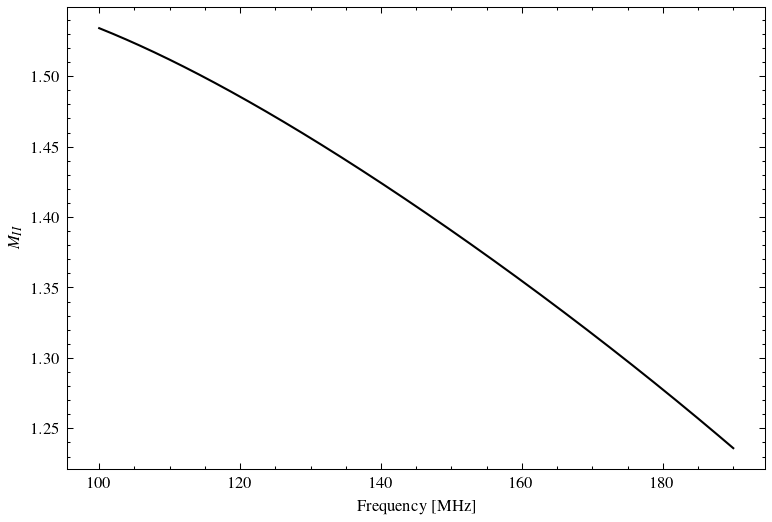

In [103]:
f_new, t_new = interp_conv_temp(nchans, freq_mhz, conv_temp_k)

mii_keys = np.array(list(mii_results.keys()))
mii_total = [] 
for key in mii_keys:
    values = mii_results[key]
    # append
    mii_total.append(values) 
    
print('MII total shape: ', np.array(mii_total).shape)
mii_avrg = np.mean(mii_total, axis=0)
print('MII average shape: ', mii_avrg.shape)

mii_key_arr = np.array(mii_keys)
duration = (mii_key_arr.max() - mii_key_arr.min())*24
print('Duration in hours: ', int(duration))
print('Start: ', mii_key_arr.min())

mii_freq = np.linspace(100.0, 190.0, len(mii_avrg))
mii_interp = np.interp(f_new, mii_freq, mii_avrg)

plt.figure(figsize=(6, 4), dpi=150)
plt.ylabel('$M_{II}$')
plt.xlabel("Frequency [MHz]")
plt.plot(f_new, mii_interp)

## Calculate Fluxes 

In [104]:
A_phys_interp = np.interp(f_new, A_phys_freq, A_phys)

width = np.array(width); snr = np.array(snr)
fluxes = []

for w, s in zip(width, snr):
      S_min = burst_smin(f_new, t_new, A_phys_interp, mii_interp, s, w*1e-3, chan_BW=0.2)
      fluxes.append(S_min)
fluxes = np.array(fluxes)

print('Brightest Pulse from transientX pulses:', np.max(fluxes)/1000, 'Jy')

ar_width = GPs_avg['Best Tau (ms)'].values; ar_snr = GPs_avg['SNR'].values
ar_fluxes = []
for w, s in zip(ar_width, ar_snr):
      S_min = burst_smin(f_new, t_new, A_phys_interp, mii_interp, s, w*1e-3, chan_BW=0.2)
      ar_fluxes.append(S_min)
ar_fluxes = np.array(ar_fluxes)
print('Brightest Pulse from fitted .ar pulses:', np.max(ar_fluxes)/1000, 'Jy')

combined_fluxes = np.concatenate((fluxes, ar_fluxes))
combined_widths = np.concatenate((width, ar_width))
combined_snrs = np.concatenate((snr, ar_snr))

print('total pulses:', len(combined_fluxes))

Brightest Pulse from transientX pulses: 443.92581552148516 Jy
Brightest Pulse from fitted .ar pulses: 2182.0980085724013 Jy
total pulses: 1046587


In [105]:
mask = combined_snrs > 10
fluxes_masked = combined_fluxes[mask]
combined_snrs_masked = combined_snrs[mask]
combined_widths_masked = combined_widths[mask]
print('Pulses with SNR > 10:', len(fluxes_masked))

Pulses with SNR > 10: 554204


In [114]:
mask = snr > 10
fluxes_masked = fluxes[mask]
snrs_masked = snr[mask]
widths_masked = width[mask]
print('Pulses with SNR > 10:', len(fluxes_masked))

Pulses with SNR > 10: 548970


## Fitting Power Law

In [118]:
def power_law(x, A, alpha):
    return A * x**(-alpha)

def fit_powLaw(data):
  bins = np.arange(10, data.max() + 10, 10)
  hist, bin_edges = np.histogram(data, bins=bins)
  right_edges = bin_edges[1:]

  xmin = 20
  mask = (hist > 0) & (right_edges >= xmin)

  x = right_edges[mask]
  y = hist[mask]

  # Fit a line in log10 space
  logx = np.log10(x)
  logy = np.log10(y)
  m, c = np.polyfit(logx, logy, 1)

  alpha = -m
  A = 10**c

  print(f"A = {A:.3g}, alpha = {alpha:.3f}")

  return bins, x, A, alpha


def fit_powerLawlog(data):
    log_min = np.log10(np.min(data[data > 0]))
    log_max = np.log10(np.max(data))
    bins = np.logspace(log_min, log_max, 30)
    hist, bin_edges = np.histogram(data, bins=bins)
    right_edges = bin_edges[1:]

    xmin = np.quantile(data, 0.05)
    mask = (hist >= 5) & (right_edges >= xmin)

    x = right_edges[mask]
    y = hist[mask]

    if len(x) < 10:
        raise ValueError("Too few bins after masking; increase bin count or data.")

    logx = np.log10(x)
    logy = np.log10(y)
    m, c = np.polyfit(logx, logy, 1, w=1/np.sqrt(y))

    alpha = -m
    A = 10**c


    return bins, x, A, alpha

def broken_pow(x, A, alpha1, beta, xbreak):
    return A * x**(-alpha1) * np.where(x < xbreak, 1, (xbreak/x)**beta)


## Plotting Results 

A = 1.27e+09, alpha = 2.758


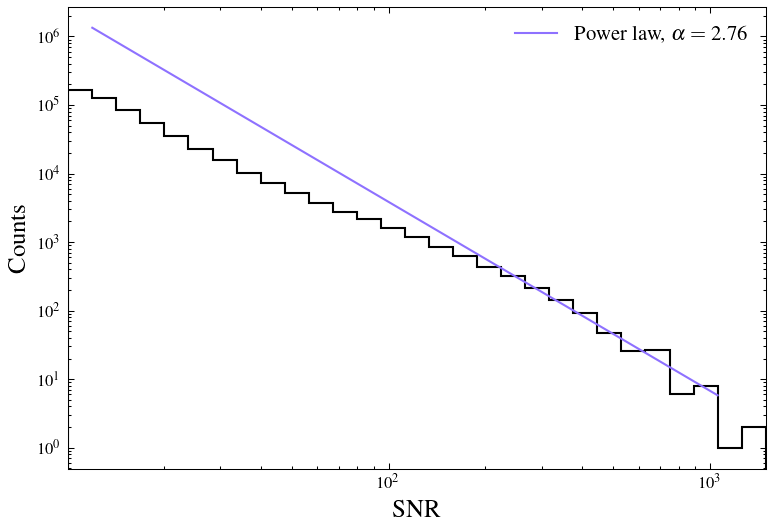

In [115]:
bins, x, A, alpha = fit_powerLawlog(snrs_masked)
plt.figure(figsize=(6, 4), dpi=150)
plt.hist(snrs_masked, bins=bins, histtype='step', color='black')
plt.plot(x, power_law(x, A, alpha), color=colors[5], label=fr'Power law, $\alpha={alpha:.2f}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('SNR', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.legend(fontsize=10)
plt.xlim(snrs_masked.min(), snrs_masked.max())
plt.savefig('./CrabGPs/CrabGP_SNR_histogram.pdf')

### Flux 

A = 6.02e+17, alpha = 3.087


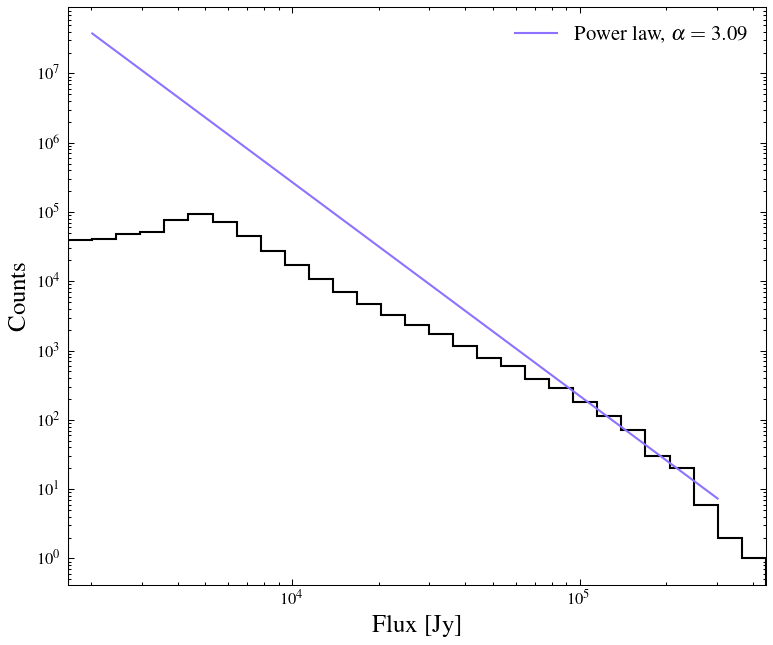

In [116]:
bins, x, A, alpha = fit_powerLawlog(fluxes_masked)

plt.figure(figsize=(6, 5), dpi=150)
plt.hist(fluxes_masked, bins=bins, histtype='step', color='black')
plt.plot(x, power_law(x, A, alpha), color=colors[5], label=fr'Power law, $\alpha={alpha:.2f}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Flux [Jy]', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.legend(fontsize=10)
plt.xlim(fluxes_masked.min(), fluxes_masked.max())
plt.savefig('./CrabGPs/CrabGP_Flux_histogram.pdf')

## Fluence Calculation

A = 3.57e+17, alpha = 2.758


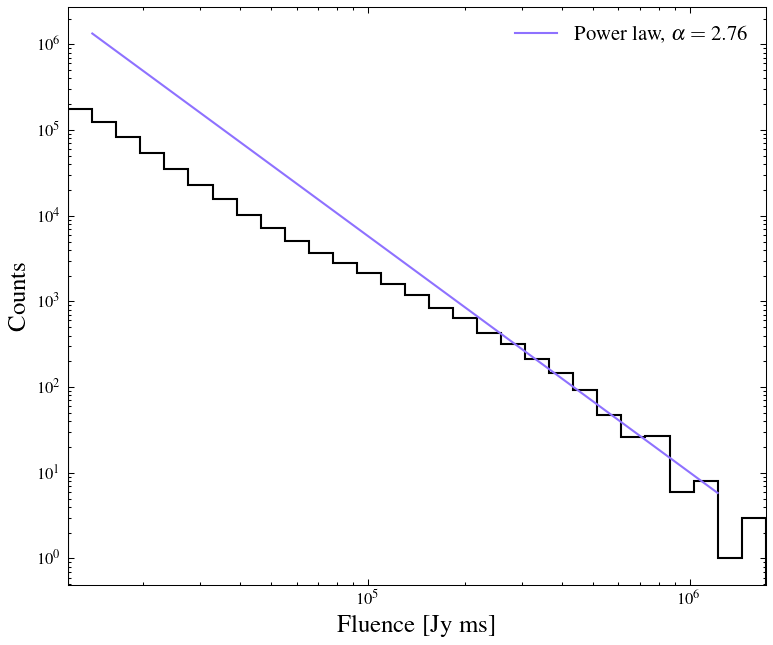

In [117]:
fluence = fluxes_masked * np.sqrt(widths_masked)

bins, x, A, alpha = fit_powerLawlog(fluence)

plt.figure(figsize=(6, 5), dpi=150)
plt.hist(fluence, bins=np.logspace(np.log10(fluence.min()), np.log10(fluence.max()), 30), histtype='step', color='black')
plt.xscale('log')
plt.yscale('log')
plt.xlim(fluence.min(), fluence.max())
plt.xlabel('Fluence [Jy ms]', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.plot(x, power_law(x, A, alpha), color=colors[5], label=fr'Power law, $\alpha={alpha:.2f}$')
plt.legend(fontsize=10)
plt.savefig('./CrabGPs/CrabGP_Fluence_histogram.pdf')